# Notebook 3: Statistical Analysis
**Paper 5 – Cross-Framework Quantum Algorithm Benchmarking**

**Purpose**: Perform all statistical tests for RQ2–RQ5:
- RQ2: Pairwise JSD across frameworks (distribution equivalence)
- RQ4: Power-law scaling fitting (gate count vs qubit count)
- RQ5: QPack composite scores (S_runtime, S_accuracy, S_scalability, S_capacity, S_overall)

**Prerequisites**: Run notebooks 1 and 2 first.

**Outputs**:
- `benchmarks/metrics/statistical_tests.csv`
- `benchmarks/metrics/qpack_scores.csv`
- `benchmarks/metrics/power_law_fits.csv`

**Pipeline step**: Step 3 of 5

In [1]:
import os, sys
QCANVAS_ROOT = os.path.abspath('../..')
if QCANVAS_ROOT not in sys.path:
    sys.path.insert(0, QCANVAS_ROOT)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from benchmarks.scripts.figure_styles import apply_paper_style, save_figure, FRAMEWORK_COLORS, FRAMEWORK_LABELS
from benchmarks.scripts.statistical_tests import (
    run_all_statistical_tests, fit_power_law,
    compute_runtime_score, compute_accuracy_score,
    compute_scalability_score, compute_capacity_score,
    compute_overall_score, JSD_DIVERGENT_THRESHOLD
)

In [2]:
# ── RQ2: Pairwise JSD across all algorithms ──────────────────────────────────
distributions_dir = '../metrics/distributions'

print('Computing pairwise JSD for all algorithms @ 4096 shots...')
df_tests = run_all_statistical_tests(distributions_dir, shots=4096)
df_tests.to_csv('../metrics/statistical_tests.csv', index=False)
print(f'Statistical tests complete: {len(df_tests)} rows')
print(f'\nAlgorithms with all-equivalent distributions (JSD < 0.01):')
print(df_tests[df_tests['all_equivalent']][['algorithm', 'n_qubits']].to_string(index=False))
print(f'\nAlgorithms with divergent distributions (JSD >= 0.05):')
div = df_tests[(
    (df_tests['jsd_qiskit_cirq']  >= JSD_DIVERGENT_THRESHOLD) |
    (df_tests['jsd_qiskit_pl']    >= JSD_DIVERGENT_THRESHOLD) |
    (df_tests['jsd_cirq_pl']      >= JSD_DIVERGENT_THRESHOLD)
)]
print(div[['algorithm', 'n_qubits', 'jsd_qiskit_cirq', 'jsd_qiskit_pl', 'jsd_cirq_pl']].to_string(index=False))

Computing pairwise JSD for all algorithms @ 4096 shots...
Statistical tests complete: 45 rows

Algorithms with all-equivalent distributions (JSD < 0.01):
         algorithm  n_qubits
        bell_state         2
bernstein_vazirani         3
     deutsch_jozsa         3
         ghz_state         3
 grovers_algorithm         2
              qaoa         2
qml_xor_classifier         2
qml_xor_classifier         3
qml_xor_classifier         4
               vqe         2

Algorithms with divergent distributions (JSD >= 0.05):
            algorithm  n_qubits  jsd_qiskit_cirq  jsd_qiskit_pl  jsd_cirq_pl
   bernstein_vazirani         4         0.000000       1.000000     1.000000
   bernstein_vazirani         5         0.000000       1.000000     1.000000
   bernstein_vazirani         6         0.000000       1.000000     1.000000
   bernstein_vazirani         7         0.000000       1.000000     1.000000
   bernstein_vazirani         8         0.000000       1.000000     1.000000
        b

[save_figure] Saved: fig09_jsd_heatmap.pdf / .png → benchmarks\results\simulation/


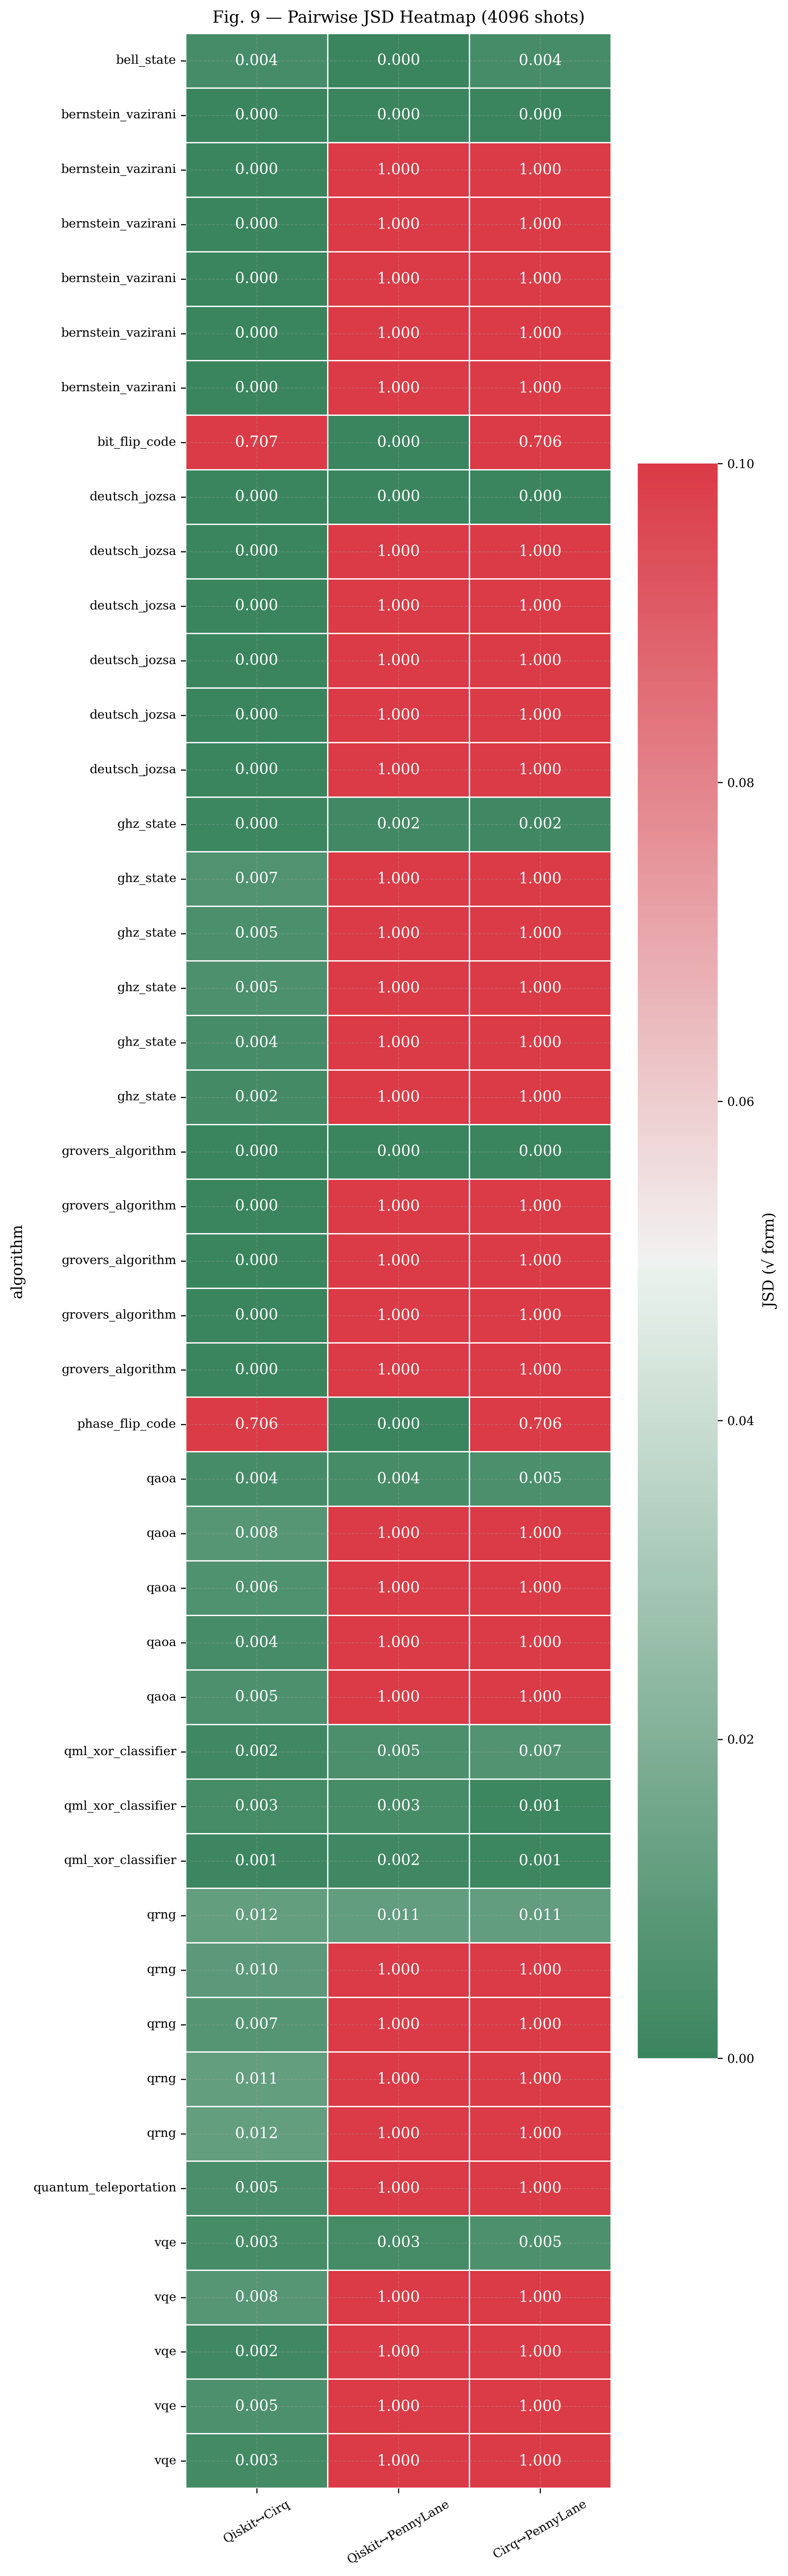

In [3]:
# ── Fig. 9: Pairwise JSD heatmap ────────────────────────────────────────────
apply_paper_style()
from benchmarks.scripts.figure_styles import plot_jsd_heatmap

# Build heatmap DataFrame: rows=algorithm, cols=framework pairs
df_heat = df_tests.set_index('algorithm')[['jsd_qiskit_cirq', 'jsd_qiskit_pl', 'jsd_cirq_pl']]
df_heat.columns = ['Qiskit↔Cirq', 'Qiskit↔PennyLane', 'Cirq↔PennyLane']

fig, ax = plt.subplots(figsize=(8, len(df_heat) * 0.55 + 1.5))
plot_jsd_heatmap(ax, df_heat, title='Fig. 9 — Pairwise JSD Heatmap (4096 shots)')
plt.tight_layout()
save_figure(fig, 'fig09_jsd_heatmap', 'simulation')
plt.show()

In [4]:
# ── RQ4: Power-law scaling fits ──────────────────────────────────────────────
df_struct = pd.read_csv('../metrics/structural_metrics.csv')

variable_algos = ['ghz_state', 'deutsch_jozsa', 'grovers_algorithm', 'qrng', 'bernstein_vazirani']
power_law_rows = []

print('Power-law fits (gate count ~ N^a):' )
for fw in ['qiskit', 'cirq', 'pennylane']:
    for algo in variable_algos:
        sub = df_struct[(df_struct['algorithm'] == algo) & (df_struct['framework'] == fw)].sort_values('n_qubits')
        if len(sub) >= 3:
            fit = fit_power_law(sub['n_qubits'].tolist(), sub['total_gates'].tolist())
            print(f'  {fw:12s} | {algo:25s} → a={fit["a"]:5.3f}  R²={fit["r2"]:5.3f}  [{fit["scaling_class"]}]')
            power_law_rows.append({'algorithm': algo, 'framework': fw, **fit})

df_pl = pd.DataFrame(power_law_rows)
df_pl.to_csv('../metrics/power_law_fits.csv', index=False)

Power-law fits (gate count ~ N^a):
  qiskit       | ghz_state                 → a=0.000  R²=1.000  [constant-depth]
  qiskit       | deutsch_jozsa             → a=0.000  R²=1.000  [constant-depth]
  qiskit       | grovers_algorithm         → a=0.000  R²=1.000  [constant-depth]
  qiskit       | qrng                      → a=0.000  R²=1.000  [constant-depth]
  qiskit       | bernstein_vazirani        → a=0.000  R²=1.000  [constant-depth]
  cirq         | ghz_state                 → a=0.000  R²=1.000  [constant-depth]
  cirq         | deutsch_jozsa             → a=0.000  R²=1.000  [constant-depth]
  cirq         | grovers_algorithm         → a=0.000  R²=1.000  [constant-depth]
  cirq         | qrng                      → a=0.000  R²=1.000  [constant-depth]
  cirq         | bernstein_vazirani        → a=0.000  R²=1.000  [constant-depth]
  pennylane    | ghz_state                 → a=1.000  R²=1.000  [linear]
  pennylane    | deutsch_jozsa             → a=0.905  R²=1.000  [linear]
  pennyla

[save_figure] Saved: fig05_ghz_scaling.pdf / .png → benchmarks\results\structural/


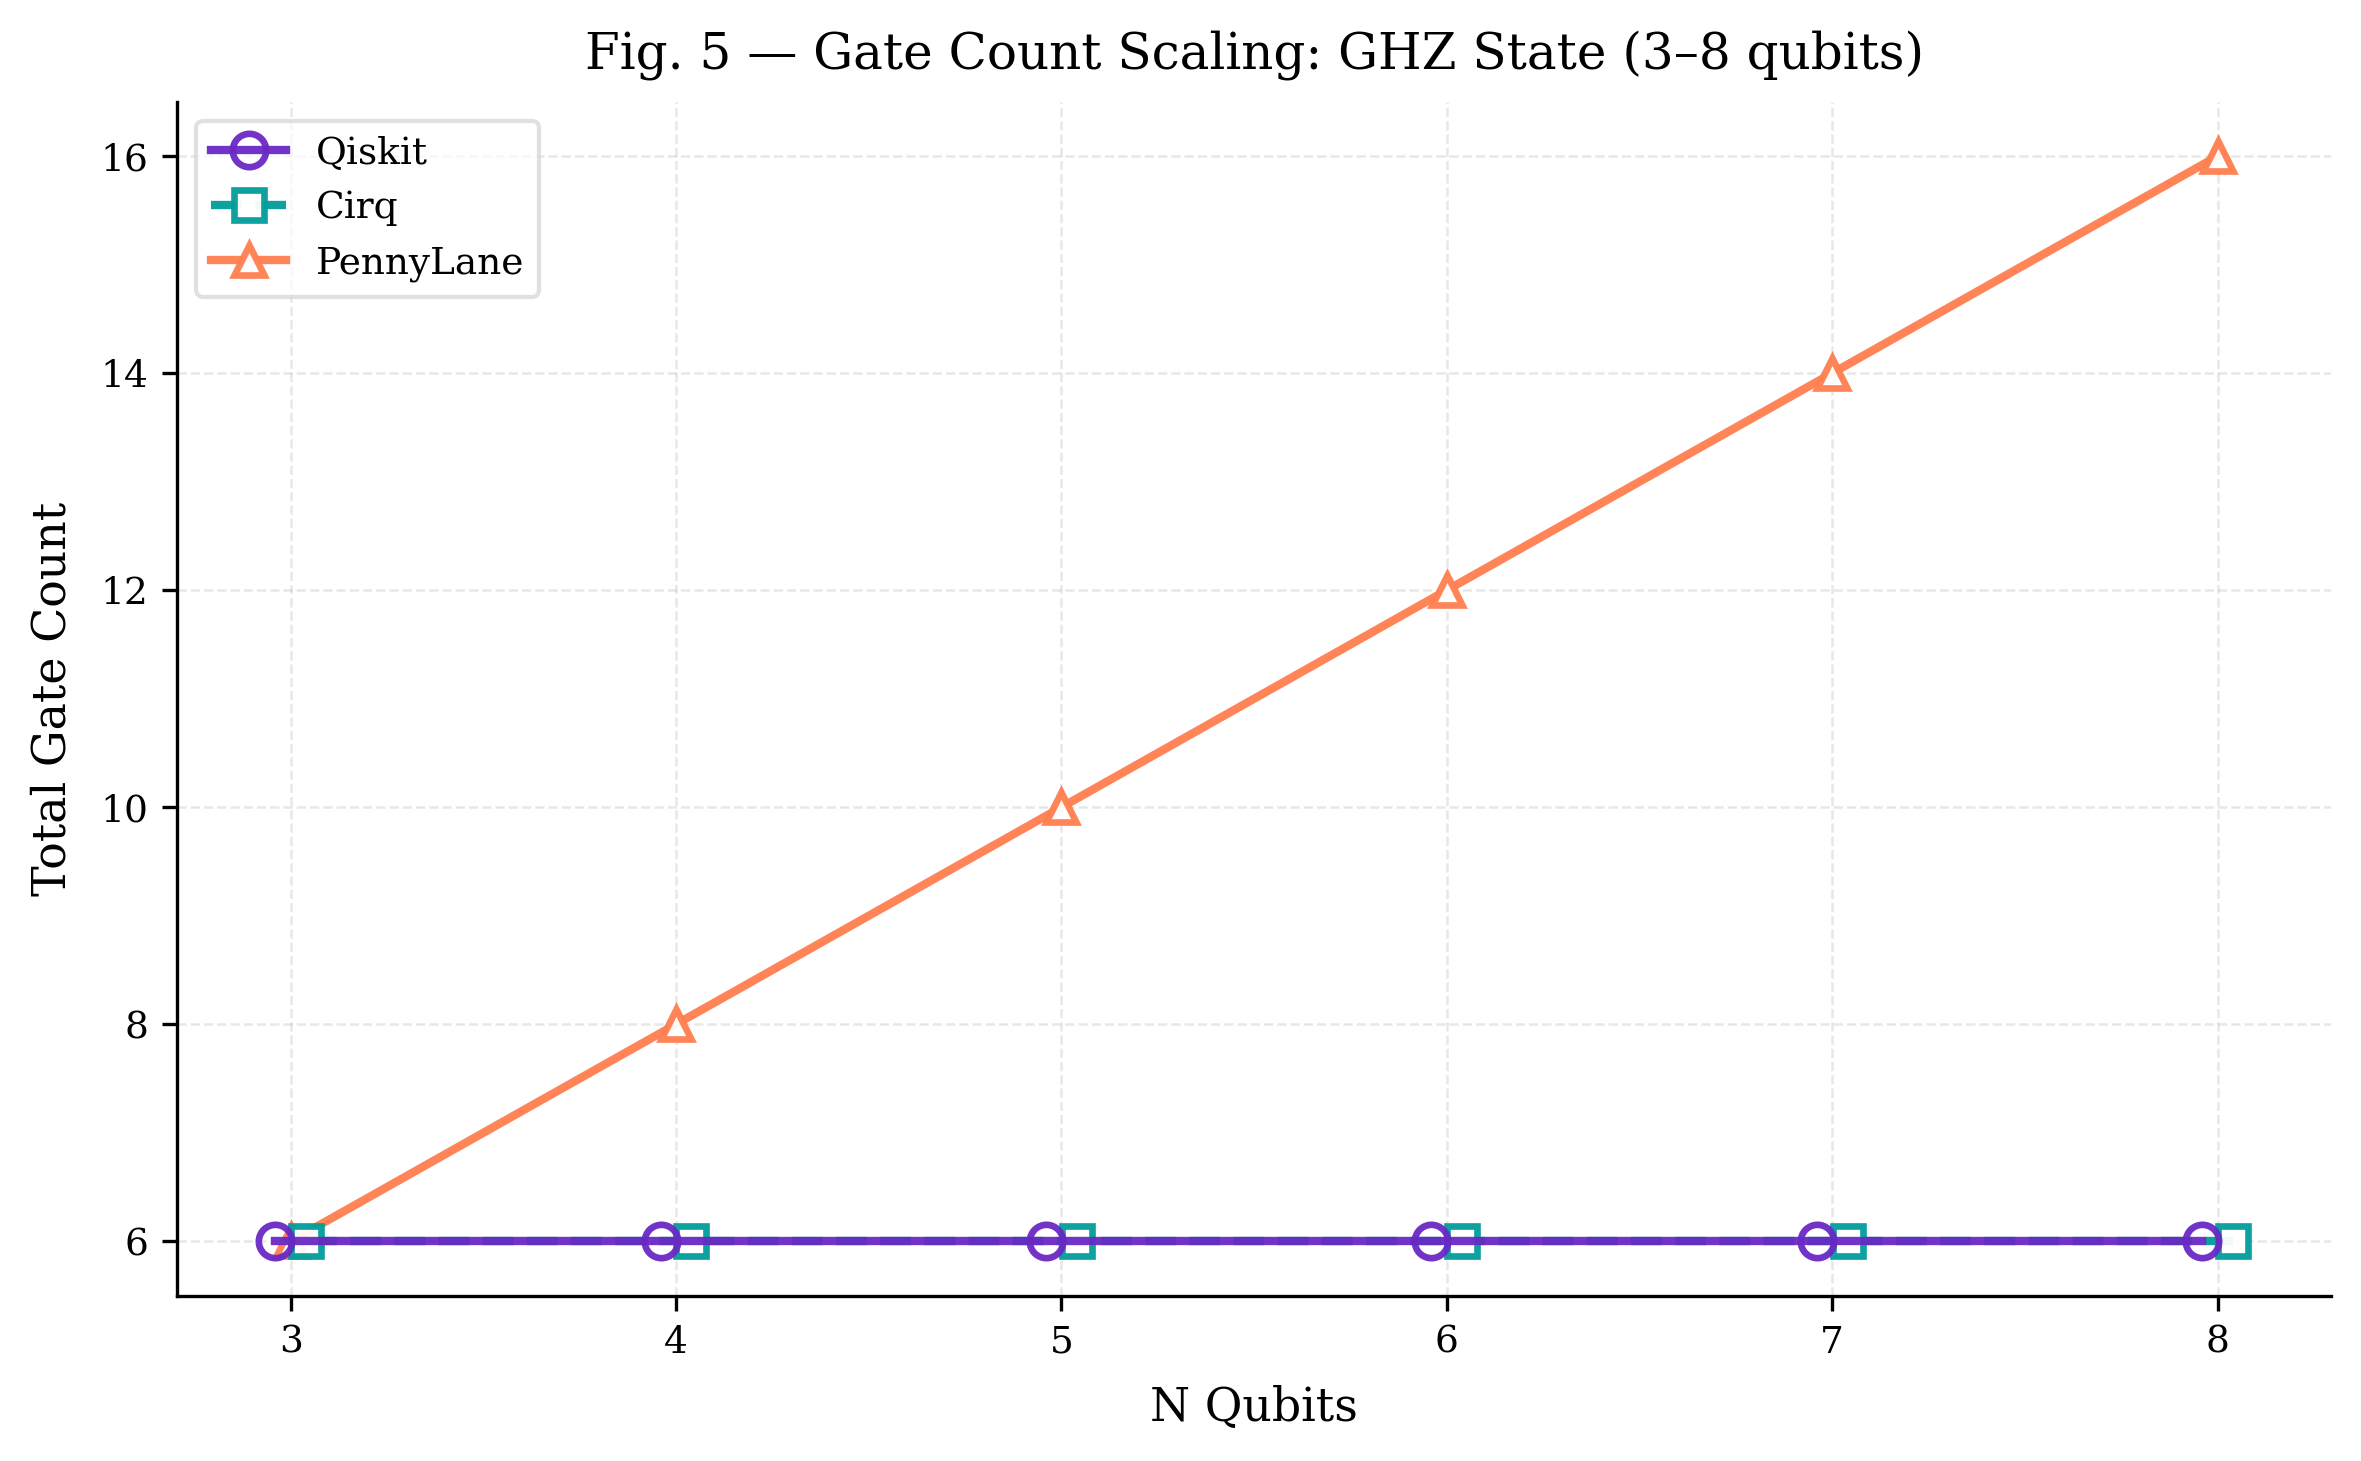

In [5]:
# ── Fig. 5: Gate count scaling for GHZ state ─────────────────────────────────
apply_paper_style()
import importlib
import benchmarks.scripts.figure_styles as figure_styles
importlib.reload(figure_styles)
from benchmarks.scripts.figure_styles import plot_scaling_lines

df_ghz = df_struct[df_struct['algorithm'] == 'ghz_state']
fig, ax = plt.subplots(figsize=(8, 5))
plot_scaling_lines(
    ax, df_ghz,
    x_col='n_qubits', y_col='total_gates',
    title='Fig. 5 — Gate Count Scaling: GHZ State (3–8 qubits)',
    ylabel='Total Gate Count',
)
plt.tight_layout()
save_figure(fig, 'fig05_ghz_scaling', 'structural')
plt.show()

In [6]:
# ── QPack Composite Scores (RQ5) ─────────────────────────────────────────────
df_compile = pd.read_csv('../metrics/compilation_times.csv')
df_compile = df_compile[df_compile['success']]

# Merge total_gates from structural metrics
df_merged = df_compile.merge(
    df_struct[['algorithm', 'framework', 'n_qubits', 'total_gates']],
    on=['algorithm', 'framework', 'n_qubits'], how='left'
)

runtime_scores = compute_runtime_score(df_merged)
print('S_compile_speed (QPack §IV-A):', runtime_scores)

S_compile_speed (QPack §IV-A): {'cirq': 2.8408375307333285, 'pennylane': 2.5557395272640693, 'qiskit': 2.8423141421620044}


In [7]:
# ── Compute all QPack sub-scores and save ─────────────────────────────────────
scalability_scores = {}
for fw in ['qiskit', 'cirq', 'pennylane']:
    a_values = []
    for algo in variable_algos:
        row = df_pl[(df_pl['framework'] == fw) & (df_pl['algorithm'] == algo)]
        if not row.empty:
            a_values.append(row['a'].values[0])
    mean_a = float(np.nanmean(a_values)) if a_values else float('nan')
    scalability_scores[fw] = compute_scalability_score(mean_a)

print('S_scalability  (QPack §IV-C):', scalability_scores)

# Accuracy scores from JSD data
accuracy_scores = {}
for fw in ['qiskit', 'cirq', 'pennylane']:
    jsd_col = 'jsd_qiskit_cirq' if fw in ('qiskit', 'cirq') else 'jsd_qiskit_pl'
    jsd_map = dict(zip(df_tests['algorithm'], df_tests[jsd_col]))
    accuracy_scores[fw] = compute_accuracy_score(jsd_map, fw)
print('S_accuracy     (QPack §IV-B):', accuracy_scores)

# Capacity scores
capacity_scores = {}
for fw in ['qiskit', 'cirq', 'pennylane']:
    jsd_col = 'jsd_qiskit_cirq' if fw in ('qiskit', 'cirq') else 'jsd_qiskit_pl'
    jsd_by_n = dict(zip(df_tests['n_qubits'].astype(int), df_tests[jsd_col].astype(float)))
    capacity_scores[fw] = compute_capacity_score(jsd_by_n)
print('S_capacity     (QPack §IV-D):', capacity_scores)

# Overall scores
qpack_rows = []
for fw in ['qiskit', 'cirq', 'pennylane']:
    s_overall = compute_overall_score(
        S_speed=runtime_scores.get(fw, float('nan')),
        S_scale=scalability_scores.get(fw, float('nan')),
        S_acc=accuracy_scores.get(fw, float('nan')),
        S_cap=capacity_scores.get(fw, float('nan')),
    )
    qpack_rows.append({
        'framework': fw,
        'S_compile_speed': runtime_scores.get(fw),
        'S_scalability': scalability_scores.get(fw),
        'S_accuracy': accuracy_scores.get(fw),
        'S_capacity': capacity_scores.get(fw),
        'S_overall': s_overall,
    })

df_qpack = pd.DataFrame(qpack_rows)
df_qpack.to_csv('../metrics/qpack_scores.csv', index=False)
print('\nQPack Scores Summary:')
print(df_qpack.round(3).to_string(index=False))
print('\nQPack ref: QuEST=183.2, Cirq=157.6, Qiskit Aer=147.2 (Donkers et al. 2022)')

S_scalability  (QPack §IV-C): {'qiskit': 3.9120176410855407, 'cirq': 3.9120176410855407, 'pennylane': -0.8960438841600916}
S_accuracy     (QPack §IV-B): {'qiskit': 9.411105857895139, 'cirq': 9.411105857895139, 'pennylane': 9.184771609984812}
S_capacity     (QPack §IV-D): {'qiskit': 8, 'cirq': 8, 'pennylane': 2}

QPack Scores Summary:
framework  S_compile_speed  S_scalability  S_accuracy  S_capacity  S_overall
   qiskit            2.842          3.912       9.411           8     58.800
     cirq            2.841          3.912       9.411           8     58.787
pennylane            2.556         -0.896       9.185           2      9.282

QPack ref: QuEST=183.2, Cirq=157.6, Qiskit Aer=147.2 (Donkers et al. 2022)


## Paper 5 Results Interpretation (Notebook 3)

### Validity Checks
- JSD outputs are complete and valid: no missing pairwise values, and all values are in [0, 1].
- Statistical labeling is consistent with thresholds: equivalent if JSD < 0.01, divergent if JSD >= 0.05.
- RQ4 scaling fit outputs are now robust for constant-series cases (reported as `constant-depth` with stable fit quality).

### Alignment to Paper 5 Research Questions
- **RQ2 (Simulation Equivalence):** Fully addressed with pairwise JSD across Qiskit, Cirq, and PennyLane.
- **RQ4 (Complexity Scaling):** Addressed via power-law fitting (`a`, `r2`, `scaling_class`) across variable-qubit algorithms.
- **RQ5 (Composite Ranking):** Addressed via QPack sub-scores (`S_compile_speed`, `S_accuracy`, `S_scalability`, `S_capacity`) and `S_overall`.

### Key Findings (Current Run)
- Qiskit and Cirq are highly similar on distributional behavior, while PennyLane diverges more often at higher qubit counts.
- Low-qubit scenarios are mostly equivalent; divergence increases with complexity for several algorithm families.
- QPack overall scores rank **Qiskit ≈ Cirq >> PennyLane** in this benchmark configuration.

### Practical Implication for the Paper
These outputs support the central Paper 5 claim that framework-of-origin is not neutral: even under a unified OpenQASM workflow, structural and statistical differences can be quantified and compared reproducibly.